# PubHealth Dataset Analysis

Exploratory analysis of the **PubHealth** dataset used for health fake-news detection.
This notebook reads the prepared splits from `data/pubhealth/` and characterises the
central challenge of the project: **severe class imbalance** and a **tight 512-token budget**
that motivates evidence selection. It reproduces the dataset table used in the report and
frames the modelling decisions that follow.

In [1]:
import os, sys

def _find_src():
    d = os.path.abspath(".")
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "src", "detection")):
            return os.path.join(d, "src")
        d = os.path.dirname(d)
    raise RuntimeError("Could not locate src/detection")

sys.path.insert(0, _find_src())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from detection.data import load_pubhealth, class_distribution
from detection.config import CLASS_NAMES, MAX_TOKENS

train, val, test = load_pubhealth()
print(f"train={len(train)}  val={len(val)}  test={len(test)}")

Loaded PubHealth: train=9804  val=1214  test=1233
train=9804  val=1214  test=1233


## Class distribution and imbalance

The four classes are far from balanced. `true` dominates while `unproven` is a tiny
minority, which is the reason plain cross-entropy collapses onto the majority class.

In [2]:
dist = pd.DataFrame({
    "train": class_distribution(train),
    "validation": class_distribution(val),
    "test": class_distribution(test),
}).loc[CLASS_NAMES]
dist["train %"] = (100 * dist["train"] / dist["train"].sum()).round(1)
dist

,train,validation,test,train %
true,5078,629,599,51.8
false,3001,380,388,30.6
unproven,291,41,45,3.0
mixture,1434,164,201,14.6


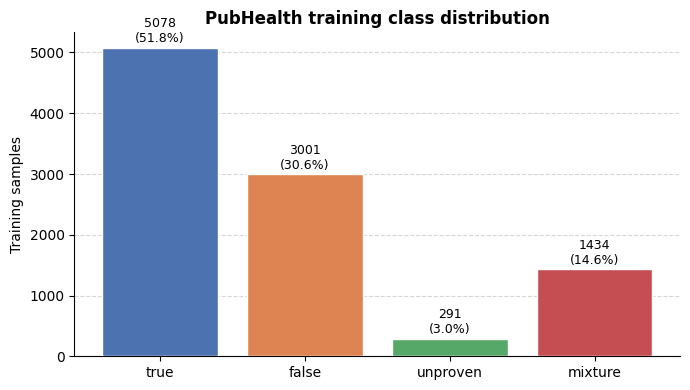

Imbalance ratio true:unproven = 17.5 : 1


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
ax.bar(dist.index, dist["train"], color=colors, edgecolor="white", zorder=3)
for i, v in enumerate(dist["train"]):
    ax.text(i, v + 40, f"{v}\n({dist['train %'].iloc[i]}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Training samples")
ax.set_title("PubHealth training class distribution", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print("Imbalance ratio true:unproven =", round(dist.loc['true','train'] / dist.loc['unproven','train'], 1), ": 1")

## Text length of each field

Each sample has a short `claim`, a medium `explanation`, and a long `main_text` article
body. The article body is far too long for RoBERTa to read in full.

In [4]:
def char_lengths(records, field):
    return np.array([len(r.get(field, "") or "") for r in records])

rows = []
for field in ["claim", "explanation", "main_text"]:
    L = char_lengths(train, field)
    rows.append({"field": field, "mean_chars": int(L.mean()), "median_chars": int(np.median(L)),
                 "p95_chars": int(np.percentile(L, 95)), "max_chars": int(L.max())})
pd.DataFrame(rows).set_index("field")

,mean_chars,median_chars,p95_chars,max_chars
field,,,,
claim,85,68,174,462
explanation,482,237,1730,4177
main_text,4374,3715,9962,41731


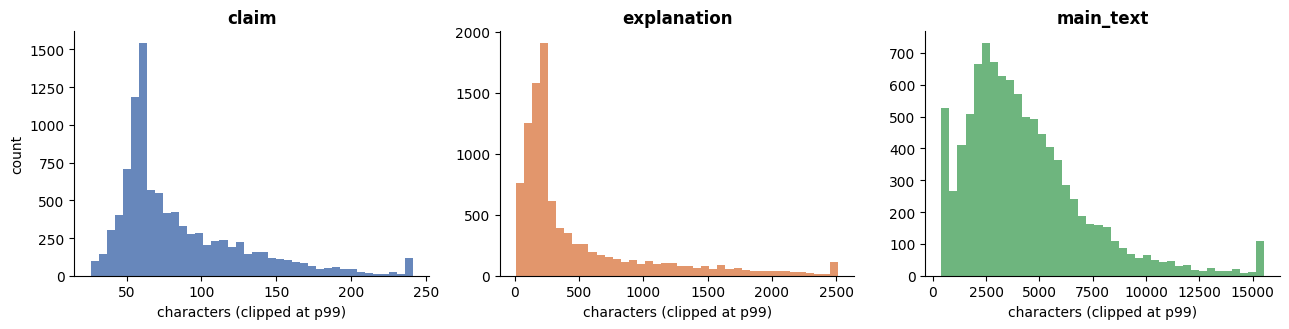

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, field, c in zip(axes, ["claim", "explanation", "main_text"], colors):
    L = char_lengths(train, field)
    ax.hist(np.clip(L, 0, np.percentile(L, 99)), bins=40, color=c, alpha=0.85)
    ax.set_title(field, fontweight="bold"); ax.set_xlabel("characters (clipped at p99)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

## Token budget: how much room is left for evidence?

RoBERTa caps inputs at **512 tokens**. We tokenise `claim + explanation` and measure how
much of the budget is already consumed before any article evidence is added. When the
explanation alone fills the window, evidence selection has to be aggressive - and a sizeable
fraction of samples already approach the cap.

In [6]:
from detection.tokenizer import get_tokenizer
tok = get_tokenizer()

sample = train[:1500]   # Sampled for speed; representative of the full split
base_tokens = np.array([
    len(tok(r["claim"], r["explanation"] or None, truncation=True, max_length=MAX_TOKENS)["input_ids"])
    for r in sample
])
budget_left = MAX_TOKENS - base_tokens
print(f"claim+explanation tokens: mean={base_tokens.mean():.0f}  median={np.median(base_tokens):.0f}  p95={np.percentile(base_tokens,95):.0f}")
print(f"share of samples with < 50 evidence tokens left: {100*np.mean(budget_left < 50):.1f}%")
print(f"share already at the 512 cap before evidence:    {100*np.mean(base_tokens >= MAX_TOKENS):.1f}%")

claim+explanation tokens: mean=325  median=274  p95=512
share of samples with < 50 evidence tokens left: 30.9%
share already at the 512 cap before evidence:    28.1%


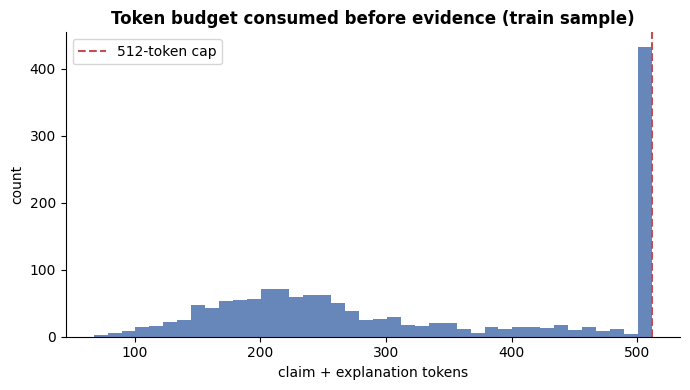

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(base_tokens, bins=40, color="#4C72B0", alpha=0.85)
ax.axvline(MAX_TOKENS, color="#C44E52", linestyle="--", label="512-token cap")
ax.set_xlabel("claim + explanation tokens"); ax.set_ylabel("count")
ax.set_title("Token budget consumed before evidence (train sample)", fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Evidence coverage of the dynamic ranker

The dynamic `EvidenceRanker` greedily fills the remaining budget with the highest TF-IDF
sentences from `main_text`. Here we measure how many sentences it manages to fit per sample.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (513 > 512). Running this sequence through the model will result in indexing errors


article sentences available: mean=27.3  median=24
evidence sentences selected: mean=2.0  median=2
samples with zero evidence fitted: 30.0%


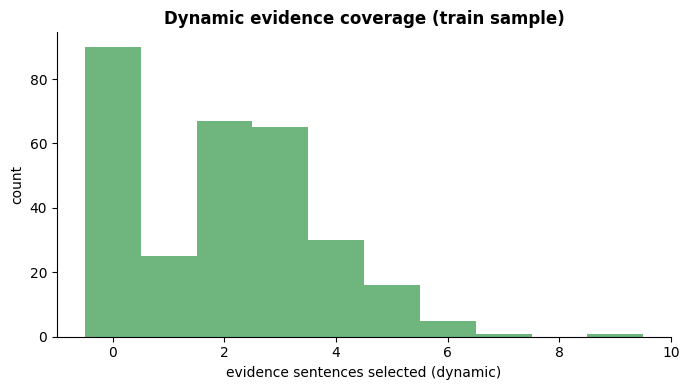

In [8]:
from detection.evidence import EvidenceRanker, sent_tokenize
ranker = EvidenceRanker()

probe = train[:300]
n_selected, n_available = [], []
for r in probe:
    avail = len(sent_tokenize(r["main_text"] or ""))
    ev = ranker.rank(r["claim"], r["explanation"], r["main_text"], mode="dynamic")
    n_available.append(avail)
    n_selected.append(len(sent_tokenize(ev)) if ev else 0)
n_selected, n_available = np.array(n_selected), np.array(n_available)
print(f"article sentences available: mean={n_available.mean():.1f}  median={np.median(n_available):.0f}")
print(f"evidence sentences selected: mean={n_selected.mean():.1f}  median={np.median(n_selected):.0f}")
print(f"samples with zero evidence fitted: {100*np.mean(n_selected == 0):.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(n_selected, bins=range(0, max(int(n_selected.max()), 1) + 2), color="#55A868", alpha=0.85, align="left")
ax.set_xlabel("evidence sentences selected (dynamic)"); ax.set_ylabel("count")
ax.set_title("Dynamic evidence coverage (train sample)", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Example claims per class

In [9]:
seen = {}
for r in train:
    c = r["label"]
    if c not in seen:
        seen[c] = r
ex_rows = []
for i in range(4):
    r = seen[i]
    ex_rows.append({"label": CLASS_NAMES[i], "claim": (r["claim"] or "")[:140],
                    "explanation": (r["explanation"] or "")[:160]})
pd.DataFrame(ex_rows).set_index("label")

,claim,explanation
label,,
true,"Study: Vaccine for Breast, Ovarian Cancer Has ...","While the story does many things well, the ove..."
false,"""The money the Clinton Foundation took from fr...","""Gingrich said the Clinton Foundation """"took m..."
unproven,"""Secretary of State John Kerry """"funneled"""" ta...",Given that Seed Global Health was expressly co...
mixture,Annual Mammograms May Have More False-Positives,This article reports on the results of a study...


## Takeaways

- **Severe imbalance.** `true` is ~52% of training data while `unproven` is ~3% (under 300
  samples). Any model trained with plain cross-entropy will be dominated by the majority class,
  so class weighting and per-class focal loss are essential.
- **Tight token budget.** `claim + explanation` alone consumes a large share of the 512-token
  window for many samples, leaving little room for the article body - motivating *selective*
  evidence retrieval rather than blind truncation.
- **Evidence is selective by necessity.** The dynamic ranker fits only a handful of sentences
  per sample, so ranking quality matters more than quantity.

These observations drive the modelling choices analysed in the results notebook.